In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("GROQ_API_KEY") is None:
    raise ValueError("GROQ_API_KEY is not set")
else:
    print("GROQ_API_KEY is set")

GROQ_API_KEY is set


In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7efc3bca2510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7efc3bca3230>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

## **Types of messages**

## There are 3 types of messages:
### 1. System message
### 2. User/Human message
### 3. Response/Assistant message

### **System message**
#### The system message is a message that is sent to the model to help it understand the task.
#### It is sent only once at the beginning of the conversation.
#### It is used to set the context of the conversation.

### **User/Human message**
#### The user message is a message that is sent to the model by the user.
#### It is sent to the model to get the response.

### **Response/Assistant message**
#### The response message is a message that is sent to the user by the model.
#### It is the response from the model to the user message.

### **Response/Assistant message** 
#### The message that is sent to the user by the model.



In [3]:
from typing import  TypedDict, List, Annotated
from operator import add
class graph_schema(TypedDict):

    messages_manual : List[str]
    messages_auto : Annotated[List, add]

    # Here we utilized both automated messaging from langgraph and also a manual messaging.
    # The difference is in automated messaging the messages are updated from one node to another automatically by langgraph but in
    # manual messaging the messages are updated manually by the user. Manual gives more control and readability to the graph.

In [4]:
from langchain_core.messages import AIMessage,HumanMessage

def create_post(state:graph_schema) -> graph_schema:


    messages_manual = state["messages_manual"]
    # messages_auto = state["messages_auto"]

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)  # We imported a new class AIMessage from langchain_core.messages to show that the response is an AI message.

    state["messages_manual"] = messages_manual + [response_manual_ai]

    # state["messages_manual"] = messages_manual
    # state["messages_auto"] = messages_auto

    return state

def refine_post(state:graph_schema) -> graph_schema:

    messages_manual = state["messages_manual"]

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)  # We imported a new class AIMessage from langchain_core.messages to show that the response is an AI message.

    state["messages_manual"] = messages_manual + [response_manual_ai]

    return state

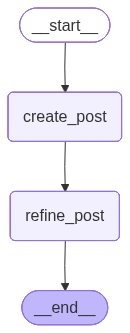

In [5]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("refine_post", refine_post)


graph.add_edge(START, "create_post")
graph.add_edge("create_post", "refine_post")
graph.add_edge("refine_post", END)

messaged_graph = graph.compile()

Image(messaged_graph.get_graph().draw_mermaid_png())

In [6]:
messaged_graph.invoke({"messages_manual": [HumanMessage(content="Write a linkedin post about the topic: AI")]})

{'messages_manual': [HumanMessage(content='Write a linkedin post about the topic: AI', additional_kwargs={}, response_metadata={}),
  AIMessage(content="**The Future of Work: How AI is Revolutionizing Industries**\n\nAs we continue to navigate the ever-changing landscape of technology, one thing is clear: Artificial Intelligence (AI) is no longer just a buzzword, but a reality that's transforming industries and revolutionizing the way we work.\n\nFrom automating mundane tasks to enhancing decision-making capabilities, AI is unlocking new possibilities and driving innovation at an unprecedented pace. Whether it's in healthcare, finance, or manufacturing, AI is helping organizations to:\n\n **Improve Efficiency**: By automating routine tasks, AI is freeing up human resources to focus on high-value tasks that require creativity, empathy, and problem-solving skills.\n\n **Enhance Customer Experience**: AI-powered chatbots and virtual assistants are providing 24/7 support, helping businesse